# Group Comparison
Compare `Churned = 0` vs `Churned = 1` profiles using model-based importance levels to prioritize analysis depth.

In [ ]:
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

palette_level = {
    'Strong': '#c8553d',
    'Moderate': '#4c956c',
    'Weak': '#577590',
    'None': '#b7b7a4'
}
churn_palette = {
    'Non-Churn': '#4c78a8',
    'Churn': '#e45756'
}
level_order = ['Strong', 'Moderate', 'Weak', 'None']

sns.set_theme(style='whitegrid')

df = pd.read_csv('../../../Data/processed/cleaned_customer_data.csv')
df_importance = pd.read_csv('../../../Data/processed/feature_importance.csv', keep_default_na=False)
df['Churn_Label'] = df['Churned'].map({0: 'Non-Churn', 1: 'Churn'})
df_importance['importance_level'] = pd.Categorical(
    df_importance['importance_level'],
    categories=level_order,
    ordered=True
)
df_importance = df_importance.sort_values(['importance_level', 'importance'], ascending=[True, False]).reset_index(drop=True)

def features_by_level(level):
    """Return feature names belonging to a given importance level."""
    return df_importance.loc[df_importance['importance_level'] == level, 'feature'].tolist()

def build_group_summary(features):
    """Build mean/median comparison table between churn groups for selected features."""
    rows = []
    for feature in features:
        grouped = df.groupby('Churned')[feature]
        rows.append({
            'feature': feature,
            'importance': df_importance.loc[df_importance['feature'] == feature, 'importance'].iloc[0],
            'level': df_importance.loc[df_importance['feature'] == feature, 'importance_level'].iloc[0],
            'mean_non_churn': grouped.mean().get(0, np.nan),
            'mean_churn': grouped.mean().get(1, np.nan),
            'median_non_churn': grouped.median().get(0, np.nan),
            'median_churn': grouped.median().get(1, np.nan),
            'gap_mean': grouped.mean().get(1, np.nan) - grouped.mean().get(0, np.nan)
        })
    return pd.DataFrame(rows).sort_values('importance', ascending=False)

def plot_group_comparison(level, kind='box'):
    """Plot churn vs non-churn distributions for all features within one importance level."""
    features = features_by_level(level)
    if not features:
        print(f'No features found for level: {level}')
        return

    ncols = 2
    nrows = math.ceil(len(features) / ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(14, 4.5 * nrows))
    axes = np.atleast_1d(axes).flatten()

    for ax, feature in zip(axes, features):
        if kind == 'violin':
            sns.violinplot(
                data=df,
                x='Churn_Label',
                y=feature,
                ax=ax,
                hue='Churn_Label',
                palette=churn_palette,
                inner='quartile',
                order=['Non-Churn', 'Churn'],
                legend=False
            )
        else:
            sns.boxplot(
                data=df,
                x='Churn_Label',
                y=feature,
                ax=ax,
                hue='Churn_Label',
                palette=churn_palette,
                width=0.6,
                order=['Non-Churn', 'Churn'],
                legend=False
            )

        importance_value = df_importance.loc[df_importance['feature'] == feature, 'importance'].iloc[0]
        ax.set_title(f'{feature}\nimportance = {importance_value:.4f}', fontsize=12, weight='bold')
        ax.set_xlabel('Customer Group')
        ax.set_ylabel(feature)

    for ax in axes[len(features):]:
        ax.remove()

    fig.suptitle(f'{level} Features: Group Comparison', fontsize=16, weight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

## Executive Summary
Start with top features and mean/median gaps between churn and non-churn groups to prioritize high-value business narratives.

,feature,importance,level,mean_non_churn,mean_churn,median_non_churn,median_churn,gap_mean
0,Lifetime_Value,0.1290,Strong,1446.81,1425.42,1266.79,1132.73,-21.38
1,Customer_Service_Calls,0.1279,Strong,5.18,6.90,5.00,7.00,1.71
2,Cart_Abandonment_Rate,0.0991,Strong,54.16,64.15,55.50,66.60,9.99
3,Discount_Usage_Rate,0.0715,Strong,42.58,39.20,40.20,38.60,-3.37
4,Age,0.0685,Strong,38.44,35.93,37.00,36.00,-2.51
5,Days_Since_Last_Purchase,0.0609,Strong,26.54,35.97,21.00,24.00,9.43
6,Total_Purchases,0.0556,Moderate,13.83,11.35,13.00,10.00,-2.48
7,Email_Open_Rate,0.0473,Moderate,22.79,16.16,21.10,14.90,-6.63
8,Average_Order_Value,0.0473,Moderate,118.38,134.76,108.94,124.40,16.38
9,Session_Duration_Avg,0.0408,Moderate,29.07,23.99,27.40,23.60,-5.08


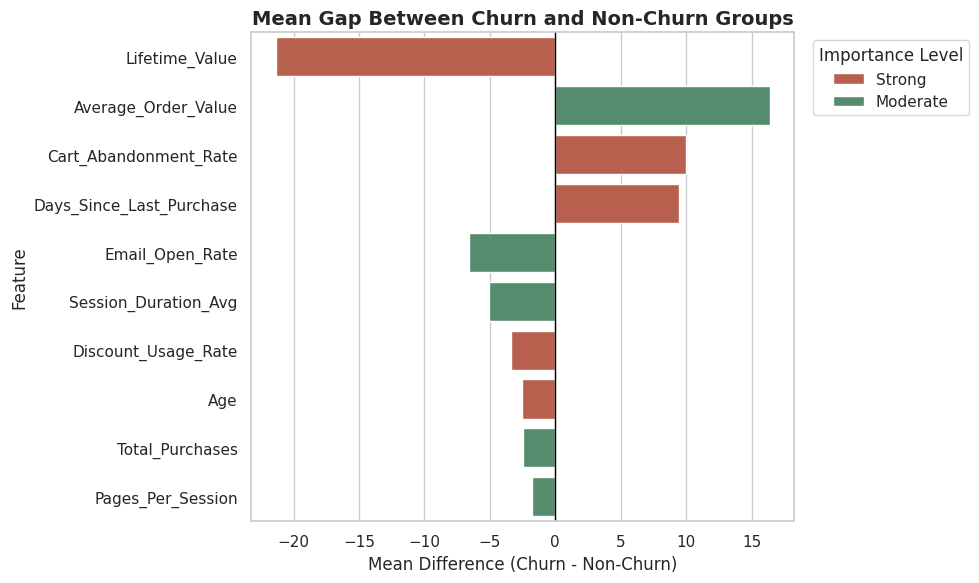

In [3]:
top_features = df_importance.sort_values('importance', ascending=False).head(12).copy()
summary_top = build_group_summary(top_features['feature'].tolist())
summary_top_display = summary_top.assign(
    importance=summary_top['importance'].round(4),
    mean_non_churn=summary_top['mean_non_churn'].round(2),
    mean_churn=summary_top['mean_churn'].round(2),
    median_non_churn=summary_top['median_non_churn'].round(2),
    median_churn=summary_top['median_churn'].round(2),
    gap_mean=summary_top['gap_mean'].round(2)
)
display(summary_top_display)

plt.figure(figsize=(10, 6))
plot_data = summary_top.sort_values('gap_mean', key=np.abs, ascending=False).head(10)
sns.barplot(
    data=plot_data,
    y='feature',
    x='gap_mean',
    hue='level',
    dodge=False,
    palette=palette_level
)
plt.axvline(0, color='black', linewidth=1)
plt.title('Mean Gap Between Churn and Non-Churn Groups', fontsize=14, weight='bold')
plt.xlabel('Mean Difference (Churn - Non-Churn)')
plt.ylabel('Feature')
plt.legend(title='Importance Level', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

## Comparison by Importance Level
Review differences tier by tier so primary churn signals are clearly separated from secondary context variables.

===== Strong =====


,feature,importance,level,mean_non_churn,mean_churn,median_non_churn,median_churn,gap_mean
0,Lifetime_Value,0.1290,Strong,1446.81,1425.42,1266.79,1132.73,-21.38
1,Customer_Service_Calls,0.1279,Strong,5.18,6.90,5.00,7.00,1.71
2,Cart_Abandonment_Rate,0.0991,Strong,54.16,64.15,55.50,66.60,9.99
3,Discount_Usage_Rate,0.0715,Strong,42.58,39.20,40.20,38.60,-3.37
4,Age,0.0685,Strong,38.44,35.93,37.00,36.00,-2.51
5,Days_Since_Last_Purchase,0.0609,Strong,26.54,35.97,21.00,24.00,9.43


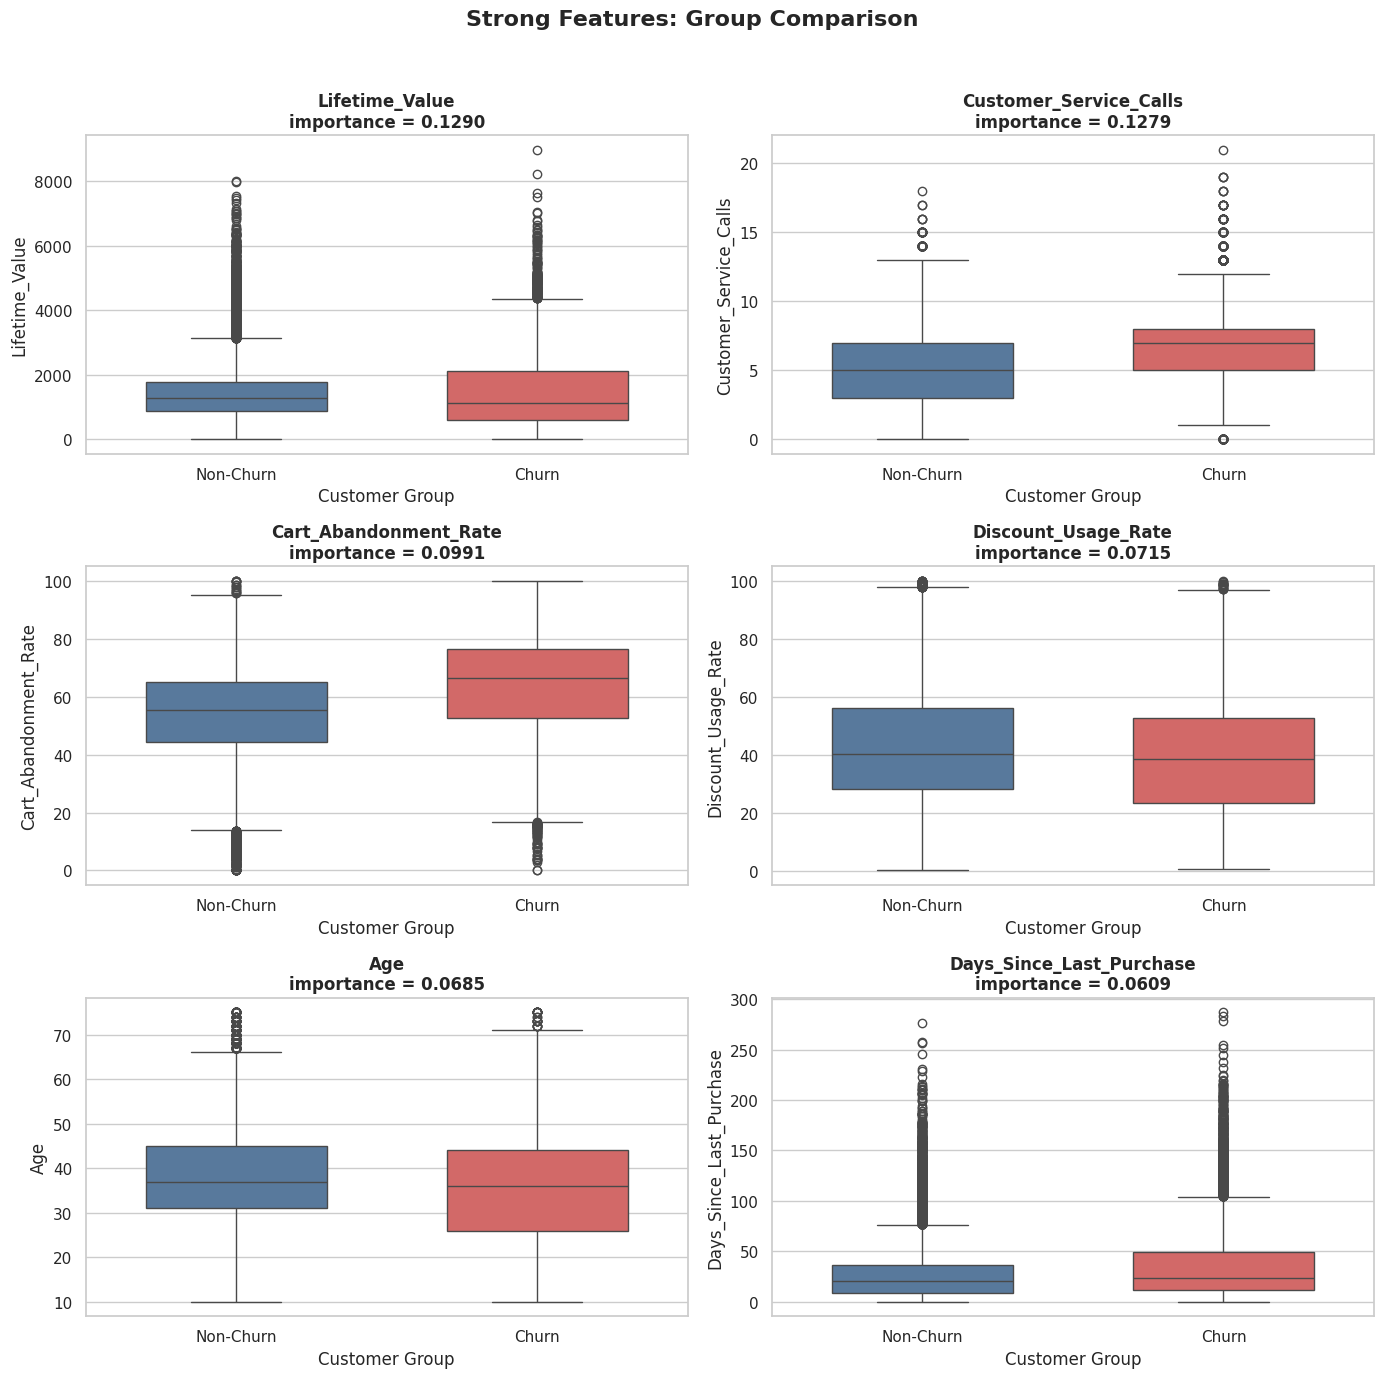

===== Moderate =====


,feature,importance,level,mean_non_churn,mean_churn,median_non_churn,median_churn,gap_mean
0,Total_Purchases,0.0556,Moderate,13.83,11.35,13.00,10.0,-2.48
1,Email_Open_Rate,0.0473,Moderate,22.79,16.16,21.10,14.9,-6.63
2,Average_Order_Value,0.0473,Moderate,118.38,134.76,108.94,124.4,16.38
3,Session_Duration_Avg,0.0408,Moderate,29.07,23.99,27.40,23.6,-5.08
4,Pages_Per_Session,0.0406,Moderate,9.24,7.43,8.70,7.2,-1.82


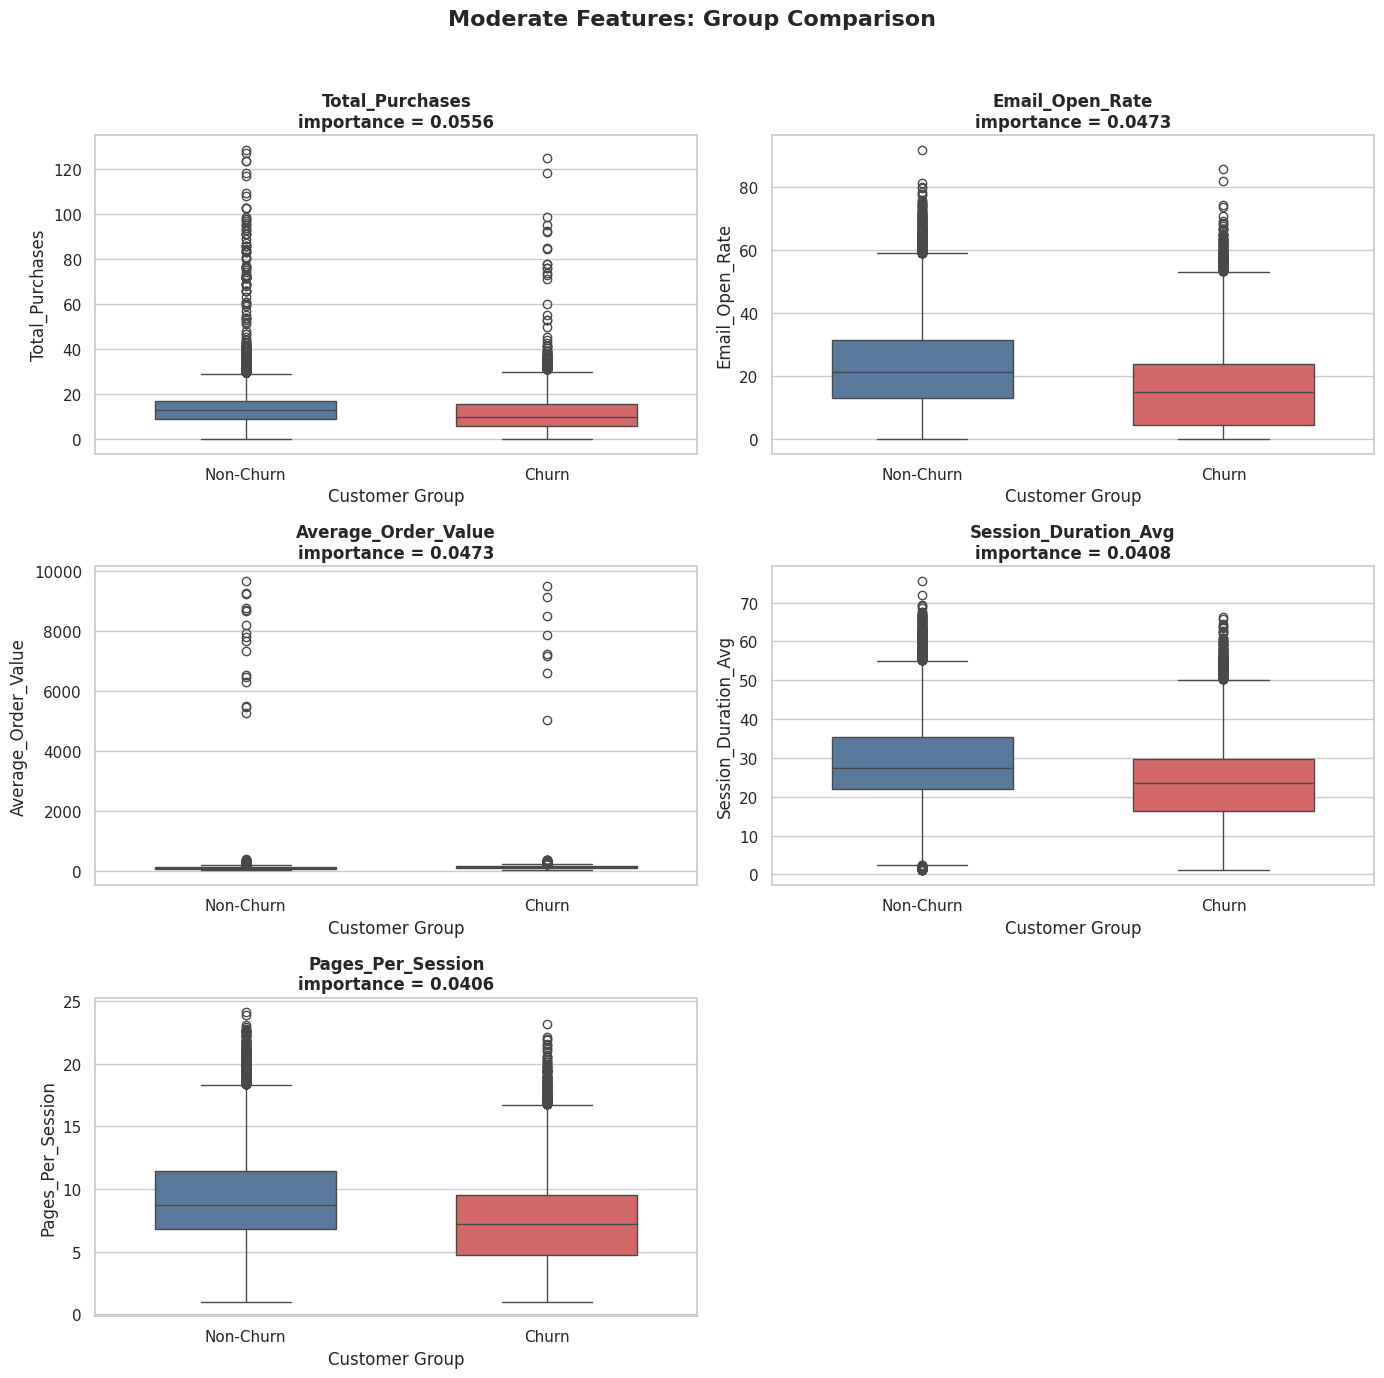

===== Weak =====


,feature,importance,level,mean_non_churn,mean_churn,median_non_churn,median_churn,gap_mean
0,Returns_Rate,0.0334,Weak,6.37,7.04,5.4,5.4,0.66
1,Mobile_App_Usage,0.0332,Weak,20.50,16.33,18.7,16.1,-4.17
2,Credit_Balance,0.0249,Weak,2067.57,1690.19,1896.0,1762.5,-377.38
3,Social_Media_Engagement_Score,0.0248,Weak,31.37,23.71,27.6,23.8,-7.66
4,Login_Frequency,0.0245,Weak,12.64,9.12,12.0,8.0,-3.52


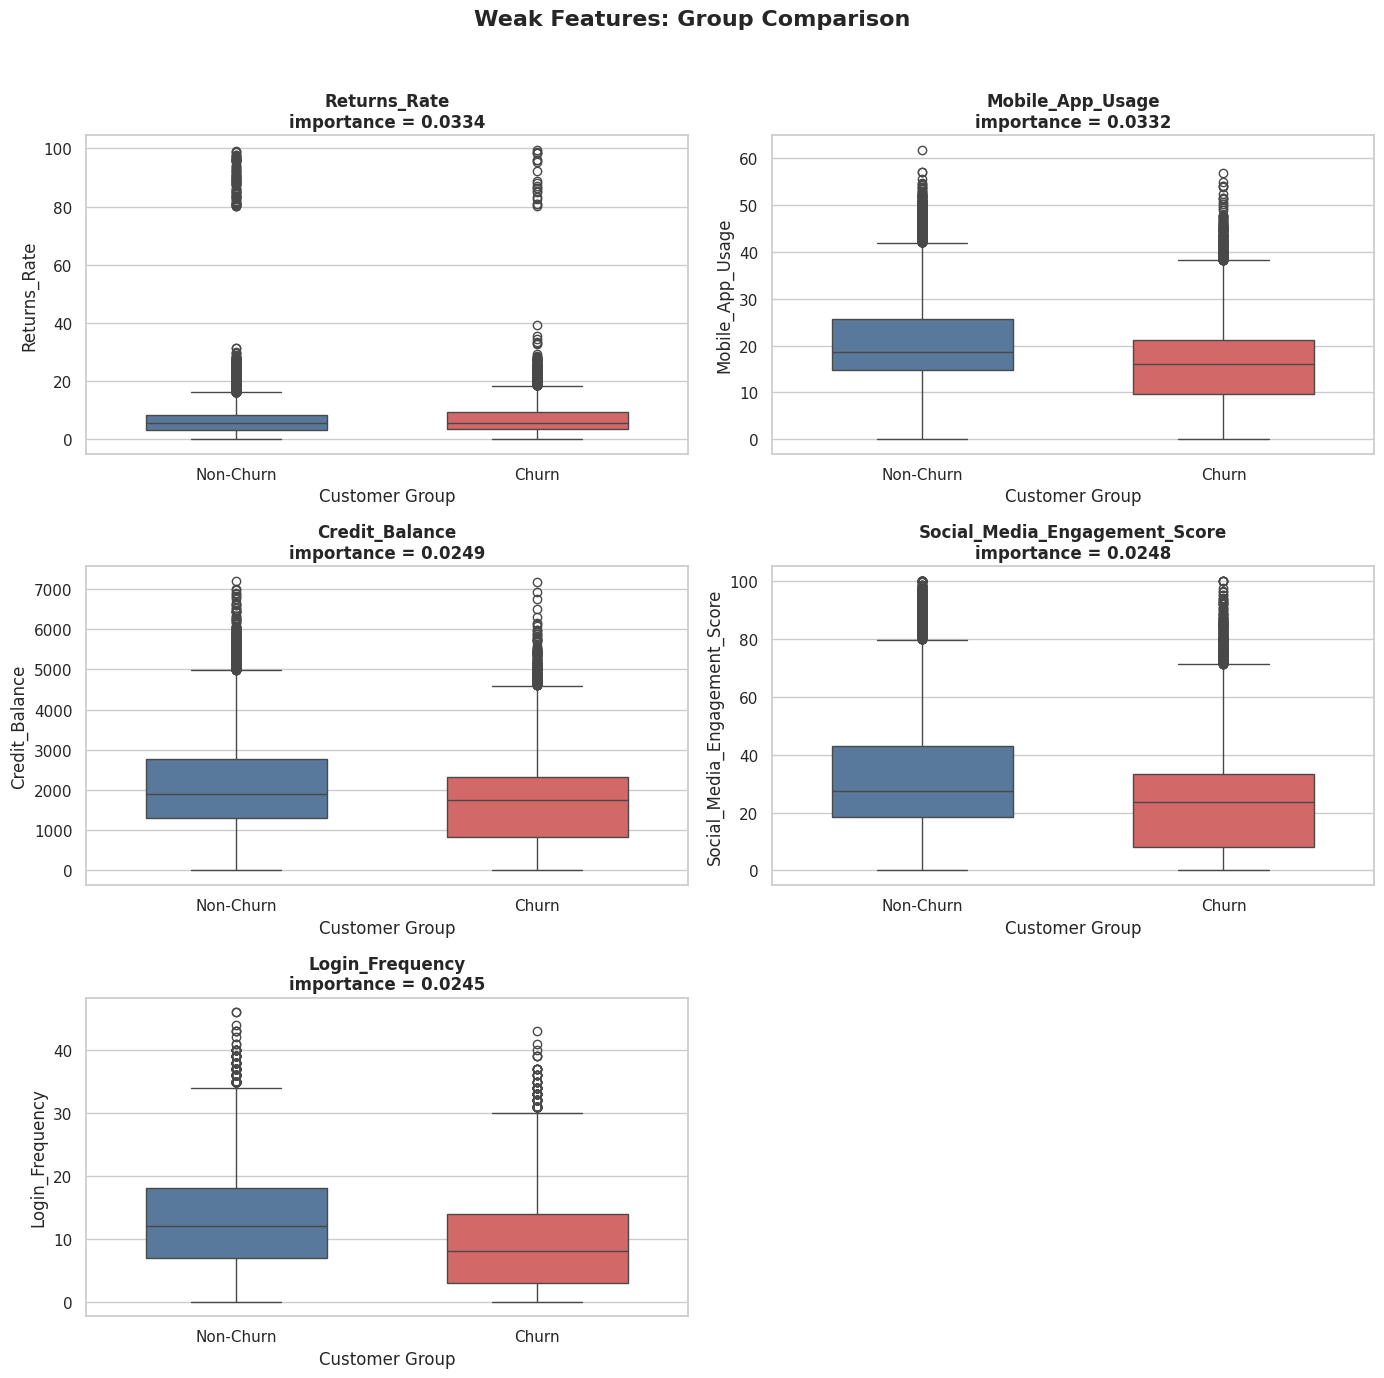

===== None =====


,feature,importance,level,mean_non_churn,mean_churn,median_non_churn,median_churn,gap_mean
0,Wishlist_Items,0.0221,None,4.64,3.36,4.0,3.0,-1.28
1,Membership_Years,0.0215,None,2.98,2.98,2.5,2.5,-0.00
2,Product_Reviews_Written,0.0159,None,3.04,2.18,3.0,2.0,-0.87
3,Payment_Method_Diversity,0.0092,None,2.33,2.34,2.0,2.0,0.01
4,Email_Open_Rate_Missing,0.0021,None,0.04,0.07,0.0,0.0,0.03


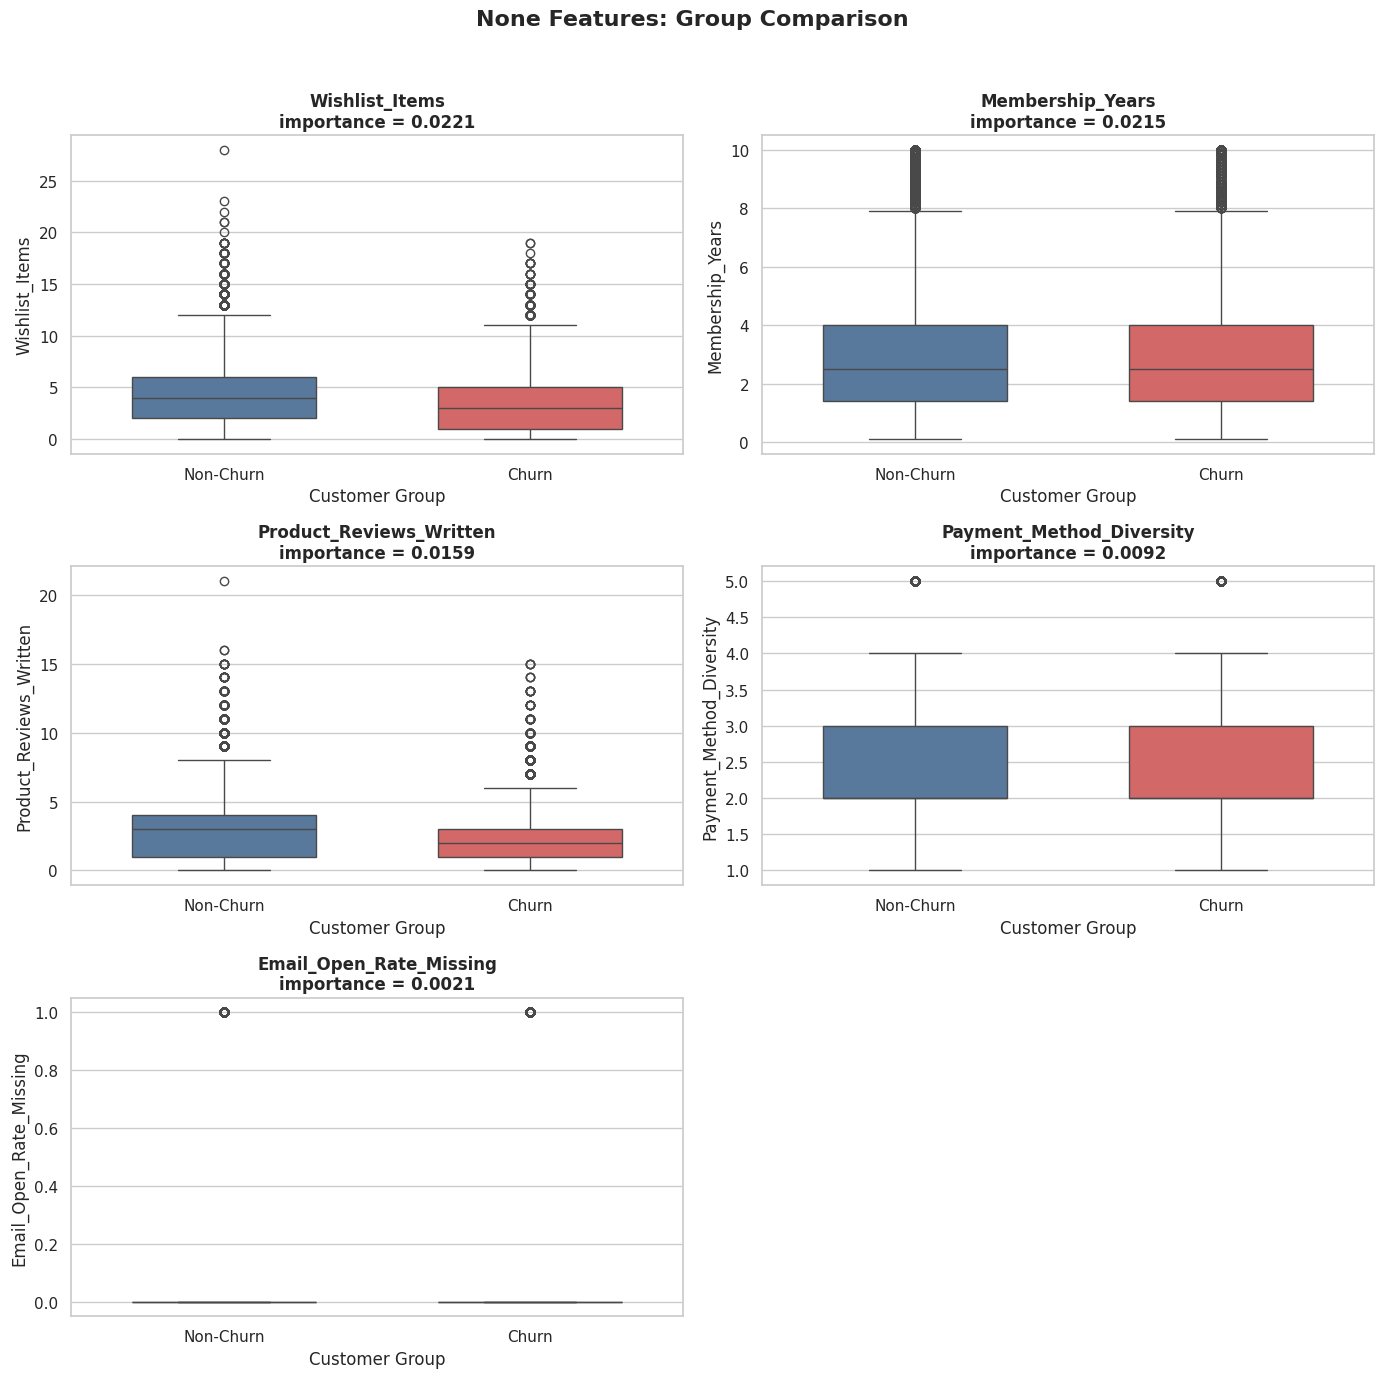

In [7]:
for level in level_order:
    features = features_by_level(level)
    if not features:
        continue

    print(f'===== {level} =====')
    level_summary = build_group_summary(features).assign(
        importance=lambda frame: frame['importance'].round(4),
        mean_non_churn=lambda frame: frame['mean_non_churn'].round(2),
        mean_churn=lambda frame: frame['mean_churn'].round(2),
        median_non_churn=lambda frame: frame['median_non_churn'].round(2),
        median_churn=lambda frame: frame['median_churn'].round(2),
        gap_mean=lambda frame: frame['gap_mean'].round(2)
    )
    display(level_summary)
    plot_group_comparison(level, kind='box')